# Tutorial 3: sequences, from tokens to RNNs to state-space models
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T03_sequences.ipynb)
Recap slides: [T03_sequences_recap.pdf](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T03_sequences_recap.pdf)

Plan for today (≈ 60 min + recap):
1. Lecture recap: tokens, RNN, BPTT, LSTM, language models, SSMs and linear attention (12 min)
2. A byte-level BPE tokenizer trained on Tiny Shakespeare (10 min)
3. RNN and LSTM cells by hand, matched to `nn.LSTM`; a character-level LM and temperature sampling (17 min)
4. A diagonal linear SSM and linear attention: recurrent form = convolution = scan; cost vs. softmax attention (18 min)
5. Gradients through time: how far back does the loss reach? (8 min)
6. If time: a GRU cell by hand

Runs on CPU (Colab or laptop) in a few minutes. Cells marked ✏️ are for you to try.

In [1]:
import math, re, time, urllib.request, warnings
warnings.filterwarnings("ignore", message="IProgress not found")
from collections import Counter
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

DATA = Path("data"); DATA.mkdir(exist_ok=True)
path = DATA / "tinyshakespeare.txt"
if not path.exists():
    urllib.request.urlretrieve("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", path)
text = path.read_text()
split = int(0.9 * len(text))
train_text, val_text = text[:split], text[split:]
print(f"{len(text):,} characters; first 200:\n{text[:200]}")

device: mps
1,115,394 characters; first 200:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 1. Lecture recap

**Tokens.** A model sees integer ids, not text. Characters give a tiny vocabulary but long sequences; words give a huge vocabulary with unknown words. **Byte-pair encoding (BPE)** sits between them: start from the 256 bytes, repeatedly merge the most frequent adjacent pair into a new token. Any string is still encodable (worst case: raw bytes).

**Vanilla (Elman) RNN.** One hidden vector, the same weights at every step:
$$h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b),\qquad y_t = W_{hy}h_t .$$

**Autoregressive language model.** $p(x_1,\dots,x_T)=\prod_t p(x_t\mid x_{<t})$. Train with teacher forcing: input $x_{1:T-1}$, target $x_{2:T}$, loss $=\frac1T\sum_t -\log p(x_{t+1}\mid x_{\le t})$. Generate by sampling one token at a time and feeding it back, with temperature $\tau$: $p \propto \exp(\text{logits}/\tau)$.

**Backprop through time (BPTT).** Unroll the graph over $T$ steps and backprop as usual; the shared $W$ sums its gradient over steps. Truncated BPTT carries the hidden state forward but backprops only through the last $k$ steps. The gradient reaching step $t$ from step $T$ is a product of Jacobians
$$\frac{\partial h_T}{\partial h_t}=\prod_{s=t+1}^{T}\mathrm{diag}\big(1-h_s^2\big)\,W_{hh},$$
which **explodes** if the largest singular value of $W_{hh}$ is $>1$ (fix: gradient clipping) and **vanishes** if it is $<1$ (fix: change the architecture).

**LSTM.** Two states, cell $c_t$ and hidden $h_t$; four gates from one matrix multiply:
$$\begin{pmatrix} i\\ f\\ o\\ g\end{pmatrix}=\begin{pmatrix}\sigma\\ \sigma\\ \sigma\\ \tanh\end{pmatrix}\Big(W\begin{pmatrix}h_{t-1}\\ x_t\end{pmatrix}+b\Big),\qquad c_t=f\odot c_{t-1}+i\odot g,\qquad h_t=o\odot\tanh(c_t).$$
From $c_t$ to $c_{t-1}$ the gradient is only multiplied elementwise by $f$, with no $W$: an additive "highway", like a ResNet skip. The GRU is a cheaper two-gate variant.

**State-space models (S4 → Mamba).** A *linear* recurrence with a fixed-size state, three views of one map:
- recurrent (inference): $h_k=\bar A h_{k-1}+\bar B x_k,\; y_k = C h_k$, $O(1)$ per token, no KV cache;
- convolutional (training): $y=\bar K * x$ with $\bar K=(C\bar B,\,C\bar A\bar B,\,C\bar A^2\bar B,\dots)$, parallel over $T$ (FFT);
- Mamba makes $\bar A,\bar B,C$ functions of the input (*selective*), which breaks the convolution; training uses a **parallel scan** instead.

**Linear attention** drops the softmax: $y_t=\sum_{s\le t}(q_t^\top k_s)v_s = S_tq_t$ with $S_t=S_{t-1}+v_tk_t^\top$, the same kind of recurrent state (Mamba-2 makes the link exact). A fixed-size state cannot store every past token, so exact recall is weaker than attention → **hybrids**: mostly linear/SSM layers plus a few full-attention layers (Jamba, Nemotron-H, Qwen3-Next 3:1, Kimi Linear).

## 2. A byte-level BPE tokenizer

Training loop (the GPT-2 recipe, minus details):
1. Split the text into "words" with a regex (a word keeps its leading space), so merges never cross word boundaries. Count each distinct word once with its frequency: much faster than scanning the raw text.
2. Represent each word as a tuple of byte values (0–255).
3. Repeat: count all adjacent pairs (weighted by word frequency), take the most frequent pair $(a,b)$, give it the next id, and replace every $(a,b)$ by that id.

The ordered list of merges *is* the tokenizer.

In [2]:
PAT = re.compile(r" ?[A-Za-z]+| ?[0-9]+| ?[^\sA-Za-z0-9]+|\s+(?!\S)|\s+")

def merge(ids, pair, new_id):
    # replace every occurrence of `pair` in the tuple `ids` by `new_id`, left to right
    out, i = [], 0
    while i < len(ids):
        if i + 1 < len(ids) and ids[i] == pair[0] and ids[i + 1] == pair[1]:
            out.append(new_id); i += 2
        else:
            out.append(ids[i]); i += 1
    return tuple(out)

def train_bpe(text, n_merges):
    words = {tuple(w.encode("utf-8")): c for w, c in Counter(PAT.findall(text)).items()}
    merges = {}                                   # (a, b) -> new id; insertion order = merge rank
    for k in range(n_merges):
        stats = Counter()
        for w, c in words.items():
            for p in zip(w, w[1:]):
                stats[p] += c
        if not stats:
            break
        pair = max(stats, key=stats.get)
        merges[pair] = 256 + k
        words = {(merge(w, pair, 256 + k) if pair[0] in w else w): c for w, c in words.items()}
    return merges

t0 = time.time()
merges = train_bpe(train_text, 500)
vocab = {i: bytes([i]) for i in range(256)}
for (a, b), i in merges.items():
    vocab[i] = vocab[a] + vocab[b]
print(f"500 merges in {time.time() - t0:.1f}s; vocab size {len(vocab)}")
print("first 15 merges:", [vocab[i].decode() for i in list(merges.values())[:15]])
print("longest tokens: ", sorted((vocab[i].decode() for i in merges.values()), key=len)[-8:])

500 merges in 21.1s; vocab size 756
first 15 merges: [' t', 'he', ' a', 'ou', ' s', ' m', 'in', ' w', 're', 'ha', ' the', 'nd', ' b', 'is', 'or']
longest tokens:  [' friend', ' honour', ' gentle', ' brother', ' RICHARD', 'GLOUCEST', 'GLOUCESTER', ' VINCENTIO']


**Encoding** a new word: start from its bytes, and repeatedly apply the merge with the **lowest rank** (learned earliest) among the adjacent pairs present, until no pair is in the table. This reproduces the order in which training built the tokens.

In [3]:
def encode_word(word, merges):
    ids = tuple(word.encode("utf-8"))
    while len(ids) >= 2:
        pair = min(zip(ids, ids[1:]), key=lambda p: merges.get(p, math.inf))
        if pair not in merges:
            break
        ids = merge(ids, pair, merges[pair])
    return ids

def encode(text, merges):
    cache, out = {}, []
    for w in PAT.findall(text):
        if w not in cache:
            cache[w] = encode_word(w, merges)
        out.extend(cache[w])
    return out

def decode(ids):
    return b"".join(vocab[i] for i in ids).decode("utf-8", errors="replace")

**Check:** the round trip must be exact on held-out text (including Unicode the training set never saw), and we compare token counts with GPT-2's tokenizer (50,257 tokens, trained on web text).

In [4]:
ids = encode(val_text, merges)
assert decode(ids) == val_text, "round trip failed"
odd = "Wherefore art thou, Röntgen? 🙂"
assert decode(encode(odd, merges)) == odd
print("round trip OK.  example:", " | ".join(decode([i]) for i in encode("To be, or not to be, that is the question:", merges)))

from transformers import AutoTokenizer
gpt2 = AutoTokenizer.from_pretrained("gpt2", model_max_length=10**8)  # we only count tokens, no 1024 limit
n_gpt2 = len(gpt2(val_text)["input_ids"])
print(f"held-out text: {len(val_text):,} chars | our BPE (756 tokens): {len(ids):,} tokens "
      f"({len(val_text) / len(ids):.2f} chars/token) | GPT-2 (50,257): {n_gpt2:,} ({len(val_text) / n_gpt2:.2f} chars/token)")

round trip OK.  example:

 To |  be | , |  or |  not |  to |  be | , |  that |  is |  the |  qu | est | ion | :


held-out text: 111,540 chars | our BPE (756 tokens): 53,225 tokens (2.10 chars/token) | GPT-2 (50,257): 36,059 (3.09 chars/token)


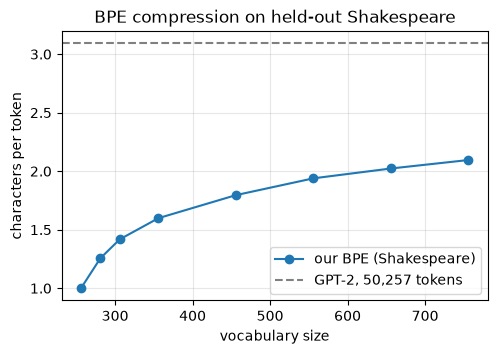

In [5]:
# compression vs. vocabulary size: encode with only the first k merges
ks = [0, 25, 50, 100, 200, 300, 400, 500]
cpt = [len(val_text) / len(encode(val_text, dict(list(merges.items())[:k]))) for k in ks]
plt.figure(figsize=(5.5, 3.5))
plt.plot([256 + k for k in ks], cpt, marker="o", label="our BPE (Shakespeare)")
plt.axhline(len(val_text) / n_gpt2, color="gray", ls="--", label="GPT-2, 50,257 tokens")
plt.xlabel("vocabulary size"); plt.ylabel("characters per token"); plt.title("BPE compression on held-out Shakespeare")
plt.legend(); plt.grid(alpha=.3); plt.show()

The first merges are space+letter and frequent letter pairs (` t`, `he`, ` a`, `ou`), then whole common words (` the`) and, specific to this corpus, speaker names (`GLOUCESTER`). Words the merges did not reach are split into pieces (` qu | est | ion`). The first 50 merges lift compression from 1 to 1.4 characters per token; the last 100 add only 0.07. With 756 tokens we reach 2.1 characters per token; GPT-2 reaches 3.1 with 66× more tokens, much of them spent on web text this corpus never uses. Sequence length is what attention pays for ($O(T^2)$), so the tokenizer is also a compute choice.

✏️ Encode a Hebrew sentence with our tokenizer and with GPT-2 and count tokens per character. Why do both fall back to (roughly) bytes?

## 3. RNN and LSTM cells by hand

PyTorch convention (row vectors, separate input and hidden biases):
$$h' = \tanh(xW_{ih}^\top + b_{ih} + hW_{hh}^\top + b_{hh}).$$
For the LSTM, `weight_ih` is $(4H\times D)$ with the gates stacked in the order **i, f, g, o**.

In [6]:
def rnn_cell(x, h, W_ih, W_hh, b_ih, b_hh):
    return torch.tanh(x @ W_ih.T + b_ih + h @ W_hh.T + b_hh)

def lstm_cell(x, state, W_ih, W_hh, b_ih, b_hh):
    h, c = state
    gates = x @ W_ih.T + b_ih + h @ W_hh.T + b_hh
    i, f, g, o = gates.chunk(4, dim=-1)
    i, f, g, o = torch.sigmoid(i), torch.sigmoid(f), torch.tanh(g), torch.sigmoid(o)
    c = f * c + i * g
    h = o * torch.tanh(c)
    return h, c

In [7]:
torch.manual_seed(0)
D, H, Bsz = 10, 20, 4
x, h0, c0 = torch.randn(Bsz, D), torch.randn(Bsz, H), torch.randn(Bsz, H)

ref = nn.RNNCell(D, H)
print("RNN cell  max |mine − torch| =", (rnn_cell(x, h0, ref.weight_ih, ref.weight_hh, ref.bias_ih, ref.bias_hh) - ref(x, h0)).abs().max().item())

ref = nn.LSTMCell(D, H)
h1, c1 = lstm_cell(x, (h0, c0), ref.weight_ih, ref.weight_hh, ref.bias_ih, ref.bias_hh)
h1_ref, c1_ref = ref(x, (h0, c0))
print("LSTM cell max |h − torch| =", (h1 - h1_ref).abs().max().item(), "  |c − torch| =", (c1 - c1_ref).abs().max().item())

RNN cell  max |mine − torch| = 5.960464477539063e-08
LSTM cell max |h − torch| = 2.9802322387695312e-08   |c − torch| = 5.960464477539063e-08


A full LSTM layer is the cell in a loop over time. We name the parameters exactly like `nn.LSTM` (`weight_ih_l0`, ...) so `load_state_dict` copies the weights across, and compare the whole output sequence and final state.

In [8]:
class MyLSTM(nn.Module):
    def __init__(self, D, H):
        super().__init__()
        k = 1 / math.sqrt(H)
        self.weight_ih_l0 = nn.Parameter(torch.empty(4 * H, D).uniform_(-k, k))
        self.weight_hh_l0 = nn.Parameter(torch.empty(4 * H, H).uniform_(-k, k))
        self.bias_ih_l0 = nn.Parameter(torch.empty(4 * H).uniform_(-k, k))
        self.bias_hh_l0 = nn.Parameter(torch.empty(4 * H).uniform_(-k, k))
        self.H = H

    def forward(self, x, state=None):            # x: (B, T, D), batch_first
        B, T, _ = x.shape
        h, c = state if state is not None else (x.new_zeros(B, self.H), x.new_zeros(B, self.H))
        outs = []
        for t in range(T):
            h, c = lstm_cell(x[:, t], (h, c), self.weight_ih_l0, self.weight_hh_l0, self.bias_ih_l0, self.bias_hh_l0)
            outs.append(h)
        return torch.stack(outs, 1), (h, c)

torch.manual_seed(0)
ref = nn.LSTM(D, H, batch_first=True)
mine = MyLSTM(D, H)
mine.load_state_dict(ref.state_dict())
xs = torch.randn(Bsz, 30, D)
out, (hT, cT) = mine(xs)
out_ref, (hT_ref, cT_ref) = ref(xs)
print("outputs max diff:", (out - out_ref).abs().max().item())
print("h_T     max diff:", (hT - hT_ref[0]).abs().max().item(), "  c_T max diff:", (cT - cT_ref[0]).abs().max().item())

outputs max diff: 5.960464477539063e-08
h_T     max diff: 5.960464477539063e-08   c_T max diff: 1.1920928955078125e-07


**Past exam question (Moed B, 2026)**

Network: INPUT → LSTM-20 → FC-10.
- INPUT: sequence length 15, feature dimension 12, i.e. input $15\times12$ with $x_t\in\mathbb{R}^{12}$.
- LSTM-20: 20 hidden units; assume the LSTM cell has 4 gates.
- FC-10: 10 output units, applied to the last hidden state.
- No bias anywhere.

Fill in the table (activation dimensions and number of learned parameters for INPUT $15\times12$ / 0, LSTM-20, FC-10). Show the LSTM parameter computation explicitly.

Each of the 4 gates has $W\in\mathbb{R}^{20\times12}$ for the input and $U\in\mathbb{R}^{20\times20}$ for the previous hidden state: LSTM $= 4(12\cdot20 + 20\cdot20) = 4\cdot640 = \mathbf{2{,}560}$; output $15\times20$ (all steps) or $20$ (last state). FC-10: $20\cdot10 = \mathbf{200}$; output $10$. The sequence length does not enter the parameter count: the weights are shared over time.

In [9]:
p_lstm = 4 * (12 * 20 + 20 * 20)
p_fc = 20 * 10
lstm_q, fc_q = nn.LSTM(12, 20, bias=False, batch_first=True), nn.Linear(20, 10, bias=False)
out_q, (h_q, _) = lstm_q(torch.zeros(1, 15, 12))
print(f"LSTM-20: yours {p_lstm}, torch {sum(p.numel() for p in lstm_q.parameters())}, outputs {tuple(out_q.shape[1:])} / last state {tuple(h_q.shape[2:])}")
print(f"FC-10  : yours {p_fc}, torch {sum(p.numel() for p in fc_q.parameters())}, output {tuple(fc_q(h_q[0]).shape[1:])}")

LSTM-20: yours 2560, torch 2560, outputs (15, 20) / last state (20,)
FC-10  : yours 200, torch 200, output (10,)


**Past exam question (Moed C, 2026)**

An LSTM layer with $d_h = 64$ hidden units runs on an input sequence with $x_t\in\mathbb{R}^{32}$. Every gate has a bias. **How many learned parameters does the layer have?** Show the computation and explain the contribution of each gate.

Four gates (input $i$, forget $f$, output $o$, candidate $g$), each $\sigma\text{ or }\tanh(Wx_t + Uh_{t-1} + b)$ with $W\in\mathbb{R}^{64\times32}$ (2,048), $U\in\mathbb{R}^{64\times64}$ (4,096), $b\in\mathbb{R}^{64}$ (64): 6,208 per gate, $4\cdot 64\cdot(32+64+1) = \mathbf{24{,}832}$.
`nn.LSTM` reports **25,088**: PyTorch (like cuDNN) keeps two bias vectors per gate, $b_{ih}$ and $b_{hh}$, i.e. $4\cdot64 = 256$ extra parameters that are redundant (only their sum matters). Both numbers are right under their convention; the exam's (one bias per gate) is 24,832.

In [10]:
d_x, d_h = 32, 64
p_lstm = 4 * d_h * (d_x + d_h + 1)
lstm_q = nn.LSTM(d_x, d_h)
print("yours (one bias per gate):", p_lstm)
print("nn.LSTM:", {n: tuple(p.shape) for n, p in lstm_q.named_parameters()}, "total", sum(p.numel() for p in lstm_q.parameters()))
print("nn.LSTM without the redundant b_hh:", sum(p.numel() for n, p in lstm_q.named_parameters() if n != "bias_hh_l0"))

yours (one bias per gate): 24832
nn.LSTM: {'weight_ih_l0': (256, 32), 'weight_hh_l0': (256, 64), 'bias_ih_l0': (256,), 'bias_hh_l0': (256,)} total 25088
nn.LSTM without the redundant b_hh: 24832


### A character-level language model

Same math, but for speed we train with `nn.LSTM` (fused kernels) now that we know what it computes. 65 distinct characters; a uniform guess costs $\ln 65 = 4.17$ nats per character. Teacher forcing: random windows of 100 characters, the target is the window shifted by one. Gradient clipping at norm 1 guards against the exploding case from the recap.

step    0  val loss 4.180  (ln V = 4.174)


step  200  train 1.817  val loss 1.874  (12s)


step  400  train 1.584  val loss 1.730  (21s)


step  600  train 1.495  val loss 1.643  (30s)


step  800  train 1.433  val loss 1.612  (39s)


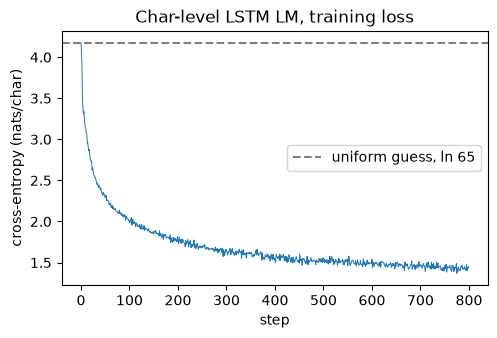

In [11]:
chars = sorted(set(text)); V = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}; itos = {i: ch for ch, i in stoi.items()}
data = torch.tensor([stoi[ch] for ch in text])
train_data, val_data = data[:split], data[split:]

def get_batch(d, B=64, T=100):
    ix = torch.randint(len(d) - T - 1, (B,))
    x = torch.stack([d[i:i + T] for i in ix]); y = torch.stack([d[i + 1:i + T + 1] for i in ix])
    return x.to(device), y.to(device)

class CharLM(nn.Module):
    def __init__(self, V, emb=64, hidden=256):
        super().__init__()
        self.emb, self.rnn, self.head = nn.Embedding(V, emb), nn.LSTM(emb, hidden, batch_first=True), nn.Linear(hidden, V)
    def forward(self, idx, state=None):
        out, state = self.rnn(self.emb(idx), state)
        return self.head(out), state

@torch.no_grad()
def val_loss(model, n=20):
    model.eval()
    l = sum(F.cross_entropy(model(x)[0].reshape(-1, V), y.reshape(-1)).item() for x, y in (get_batch(val_data) for _ in range(n))) / n
    model.train(); return l

torch.manual_seed(0)
lm = CharLM(V).to(device)
opt = torch.optim.AdamW(lm.parameters(), lr=3e-3)
STEPS = 800                                     # Colab GPU: hidden=512, 2 layers, 5000 steps
losses, t0 = [], time.time()
print(f"step    0  val loss {val_loss(lm):.3f}  (ln V = {math.log(V):.3f})")
for step in range(1, STEPS + 1):
    x, y = get_batch(train_data)
    logits, _ = lm(x)
    loss = F.cross_entropy(logits.reshape(-1, V), y.reshape(-1))
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(lm.parameters(), 1.0)
    opt.step(); losses.append(loss.item())
    if step % 200 == 0:
        print(f"step {step:4d}  train {np.mean(losses[-50:]):.3f}  val loss {val_loss(lm):.3f}  ({time.time() - t0:.0f}s)")

plt.figure(figsize=(5.5, 3.3)); plt.plot(losses, lw=.7)
plt.axhline(math.log(V), color="gray", ls="--", label="uniform guess, ln 65")
plt.xlabel("step"); plt.ylabel("cross-entropy (nats/char)"); plt.title("Char-level LSTM LM, training loss"); plt.legend(); plt.show()

**Sampling.** Feed the prompt once to get the state, then loop: divide the last logits by the temperature $\tau$, softmax, draw one character, feed it back with the carried state. $\tau\to0$ is greedy argmax; $\tau=1$ is the model's distribution; $\tau>1$ flattens it.

In [12]:
@torch.no_grad()
def sample(model, prompt, n=250, temperature=1.0):
    model.eval()
    idx = torch.tensor([[stoi[c] for c in prompt]], device=device)
    logits, state = model(idx)
    out = list(prompt)
    for _ in range(n):
        probs = F.softmax(logits[0, -1] / temperature, dim=-1)
        nxt = torch.multinomial(probs, 1)
        out.append(itos[nxt.item()])
        logits, state = model(nxt.view(1, 1), state)
    return "".join(out)

@torch.no_grad()
def greedy(model, prompt, n=250):
    idx = torch.tensor([[stoi[c] for c in prompt]], device=device)
    logits, state = model(idx); out = list(prompt)
    for _ in range(n):
        nxt = logits[0, -1].argmax().view(1, 1)
        out.append(itos[nxt.item()]); logits, state = model(nxt, state)
    return "".join(out)

print("τ → 0 equals greedy argmax:", sample(lm, "ROMEO:", temperature=1e-4) == greedy(lm, "ROMEO:"))

τ → 0 equals greedy argmax: True


In [13]:
for tau in [0.5, 1.0, 1.5]:
    torch.manual_seed(1)
    print(f"----- temperature {tau} -----\n{sample(lm, 'ROMEO:', temperature=tau)}\n")

----- temperature 0.5 -----
ROMEO:
What not thou art the tate to deep his honour,
To see the prosorrost the duke of his scare is a storn in the torth
Off and to the first which the father?

LEONTES:
Well, I have go the despessed art on the cheeds.

CORIOLANUS:
What is the world, that



----- temperature 1.0 -----
ROMEO:
Worthy York in his new--!
Then, hast's line returns; an old's ourscend steeds of his liptees day, our early
Than son for leake--inker be times sister labost
To thy sender's warm
Had to depeleve a thousand there's enemy.

And HenrY Couzan:
But with y



----- temperature 1.5 -----
ROMEO:
Wo,
ThiY zath mescanes--! you never I:
You, rity to Joun lompsorrs. This did.

MERCUTI:
He's dayD our earches
fits tyfumple,
Horse;
All my desessufur labost Tistury's douqure:.'
3 Whosefliese--Harth Henrancher, sleed-Hy
sentent, and viace, hin?
O, y



After 800 steps the validation loss is ≈1.6 nats/char (from 4.17). The model has the format: speaker names in capitals followed by a colon, line breaks, short lines. At $\tau=0.5$ almost every word is real and the phrasing is generic ("What is the world, that"); at $\tau=1$ invented words appear; at $\tau=1.5$ there are capitals inside words and broken names (`MERCUTI:`). The lecture's "train more" slides show the same progression with training time.
✏️ Swap `nn.LSTM` for `nn.RNN` in `CharLM`, train the same 800 steps, and compare the validation loss. Then train on our BPE ids instead of characters: what changes in the loss value and why can't you compare it directly to the character-level number?

## 4. Linear recurrences: SSMs and linear attention

**Diagonal linear SSM** (S4D/Mamba style, already discretized). Each of the $D$ input channels has its own $N$-dimensional state with diagonal decay $a\in(0,1)^{D\times N}$:
$$h_t = a\odot h_{t-1} + b\odot x_t,\qquad y_t=\textstyle\sum_n c_n h_{t,n}.$$
Unrolling, $h_t=\sum_{s\le t}a^{t-s}b\,x_s$, so $y = K * x$ with kernel $K_k=\sum_n c_n a_n^k b_n$ (one causal convolution per channel). The recurrence never mixes channels: a full model puts linear layers and gating between SSM layers.

In [14]:
def ssm_recurrent(x, a, b, c):
    # x: (B, T, D); a, b, c: (D, N), or a: (B, T, D, N) when it changes with time (selective)
    B, T, D = x.shape
    h = x.new_zeros(B, D, b.shape[-1]); ys = []
    for t in range(T):
        a_t = a[:, t] if a.dim() == 4 else a
        h = a_t * h + b * x[:, t, :, None]
        ys.append((c * h).sum(-1))
    return torch.stack(ys, 1)

def ssm_kernel(a, b, c, T):
    k = torch.arange(T, dtype=a.dtype)
    return (c * b * a[None] ** k[:, None, None]).sum(-1)

def causal_conv_fft(x, K):
    # y[:, t, d] = Σ_{s≤t} K[t−s, d] x[:, s, d]; zero-pad to 2T so the circular FFT convolution does not wrap around
    T = x.shape[1]
    return torch.fft.irfft(torch.fft.rfft(x, n=2 * T, dim=1) * torch.fft.rfft(K, n=2 * T, dim=0), n=2 * T, dim=1)[:, :T]

In [15]:
torch.manual_seed(0)
Bsz, T, D, N = 2, 256, 4, 8
x = torch.randn(Bsz, T, D, dtype=torch.float64)
a = torch.exp(-torch.exp(torch.empty(D, N, dtype=torch.float64).uniform_(math.log(1e-3), math.log(1e-1))))  # decays 0.90–0.999
b, c = torch.randn(D, N, dtype=torch.float64), torch.randn(D, N, dtype=torch.float64)

y_rec = ssm_recurrent(x, a, b, c)
K = ssm_kernel(a, b, c, T)
y_fft = causal_conv_fft(x, K)
# library reference: grouped conv1d (cross-correlation, so flip the kernel and left-pad)
y_conv = F.conv1d(F.pad(x.transpose(1, 2), (T - 1, 0)), K.T.flip(-1).unsqueeze(1), groups=D).transpose(1, 2)
print("recurrent vs FFT conv    max diff:", (y_rec - y_fft).abs().max().item())
print("recurrent vs F.conv1d    max diff:", (y_rec - y_conv).abs().max().item())

recurrent vs FFT conv    max diff: 1.2789769243681803e-13
recurrent vs F.conv1d    max diff: 1.5631940186722204e-13


**Selective SSM (Mamba).** If $a_t$ depends on the input $x_t$, the kernel is different at every step and the convolution view is gone. The recurrence $h_t=a_th_{t-1}+u_t$ (with $u_t=b\,x_t$) is still parallel, because composing two steps is again a step of the same form:
$$(a_1,u_1)\circ(a_2,u_2) = (a_2a_1,\; a_2u_1+u_2).$$
This operator is associative, so a **scan** computes all prefixes in $\log_2 T$ vectorized rounds (Hillis–Steele): in round $r$, every position combines with the one $2^r$ steps back.

In [16]:
def scan(A, U):
    # all h_t for h_t = A_t ⊙ h_{t−1} + U_t, h_0 = 0; time is dim 1; log2(T) rounds
    off = 1
    while off < A.shape[1]:
        U = torch.cat([U[:, :off], A[:, off:] * U[:, :-off] + U[:, off:]], 1)
        A = torch.cat([A[:, :off], A[:, off:] * A[:, :-off]], 1)
        off *= 2
    return U

# input-dependent decay, a toy version of Mamba's selection: a_t = σ(w ⊙ x_t + 3)
w = torch.randn(D, N, dtype=torch.float64)
a_sel = torch.sigmoid(w * x[..., None] + 3)                   # (B, T, D, N)
y_rec_sel = ssm_recurrent(x, a_sel, b, c)
h_scan = scan(a_sel, b * x[..., None])                         # (B, T, D, N)
y_scan = (c * h_scan).sum(-1)
print(f"selective: recurrent vs scan max diff: {(y_rec_sel - y_scan).abs().max().item():.2e}  ({math.ceil(math.log2(T))} rounds instead of {T} steps)")
print(f"time-invariant: scan vs recurrent max diff: {((c * scan(a.expand(Bsz, T, D, N), b * x[..., None])).sum(-1) - y_rec).abs().max().item():.2e}")

selective: recurrent vs scan max diff: 1.07e-14  (8 rounds instead of 256 steps)
time-invariant: scan vs recurrent max diff: 5.68e-14


**Linear attention** is the same object with a matrix-valued state. With decay $\gamma\in(0,1]$ ($\gamma=1$: plain linear attention; $\gamma<1$: RetNet / a scalar-decay Mamba-2 head):
$$S_t=\gamma S_{t-1}+v_tk_t^\top,\quad y_t=S_tq_t \qquad\Longleftrightarrow\qquad Y=\big((QK^\top)\odot M\big)V,\quad M_{ts}=\begin{cases}\gamma^{t-s}& s\le t\\ 0 & s>t\end{cases}$$
Left: recurrent, $O(d^2)$ state, $O(1)$ per token. Right: parallel, like attention without the softmax.

In [17]:
def linattn_recurrent(q, k, v, gamma=1.0):
    B, T, d = q.shape
    S = q.new_zeros(B, d, d); ys = []
    for t in range(T):
        S = gamma * S + v[:, t, :, None] * k[:, t, None, :]
        ys.append((S @ q[:, t, :, None]).squeeze(-1))
    return torch.stack(ys, 1)

def linattn_parallel(q, k, v, gamma=1.0):
    T = q.shape[1]
    t = torch.arange(T)
    M = torch.where(t[:, None] >= t[None, :], gamma ** (t[:, None] - t[None, :]).to(q.dtype), torch.zeros((), dtype=q.dtype))
    return ((q @ k.transpose(1, 2)) * M) @ v

torch.manual_seed(0)
q, k, v = (torch.randn(2, 128, 16, dtype=torch.float64) for _ in range(3))
for gamma in [1.0, 0.9]:
    print(f"γ = {gamma}: recurrent vs parallel max diff {(linattn_recurrent(q, k, v, gamma) - linattn_parallel(q, k, v, gamma)).abs().max().item():.2e}")

γ = 1.0: recurrent vs parallel max diff 1.42e-13
γ = 0.9: recurrent vs parallel max diff 1.42e-14


Neither form above is what fast kernels use: the recurrent form is a Python loop over $T$, the parallel form builds a $T\times T$ matrix. Real implementations (Mamba-2, GLA, Gated DeltaNet) are **chunked**: parallel attention-like form inside chunks of $C$ tokens, the recurrent state carried between chunks. Cost $O(TCd + Td^2)$, linear in $T$.

In [18]:
def linattn_chunked(q, k, v, C=64):
    B, T, d = q.shape
    S = q.new_zeros(B, d, d); out = []
    mask = torch.tril(torch.ones(C, C, dtype=q.dtype))
    for i in range(0, T, C):
        qc, kc, vc = q[:, i:i + C], k[:, i:i + C], v[:, i:i + C]
        m = mask[:qc.shape[1], :qc.shape[1]]
        out.append(((qc @ kc.transpose(1, 2)) * m) @ vc + qc @ S.transpose(1, 2))   # within chunk + from earlier chunks
        S = S + vc.transpose(1, 2) @ kc                                               # Σ v kᵀ over the chunk
    return torch.cat(out, 1)

print("chunked vs parallel max diff:", (linattn_chunked(q, k, v, C=32) - linattn_parallel(q, k, v)).abs().max().item())

chunked vs parallel max diff: 1.1368683772161603e-13


**Cost vs. sequence length.** Causal softmax attention (materialized $T\times T$ scores, as in a naive implementation), chunked linear attention, and the SSM via FFT convolution, on CPU, one sequence, $d=64$. The right panel is memory at **generation** time: attention keeps a KV cache that grows with every token; the linear layers keep a fixed state.

T=   256  softmax attention:     0.6 ms  linear attention (chunked):     0.5 ms  SSM (FFT conv):     4.3 ms


T=   512  softmax attention:     1.9 ms  linear attention (chunked):     0.4 ms  SSM (FFT conv):    13.3 ms


T=  1024  softmax attention:    12.4 ms  linear attention (chunked):     1.7 ms  SSM (FFT conv):    11.7 ms


T=  2048  softmax attention:    20.5 ms  linear attention (chunked):     1.8 ms  SSM (FFT conv):    24.5 ms


T=  4096  softmax attention:    57.8 ms  linear attention (chunked):     3.0 ms  SSM (FFT conv):    37.3 ms


T=  8192  softmax attention:   257.6 ms  linear attention (chunked):     7.1 ms  SSM (FFT conv):    81.4 ms


T= 16384  softmax attention:     nan ms  linear attention (chunked):    20.2 ms  SSM (FFT conv):   178.1 ms


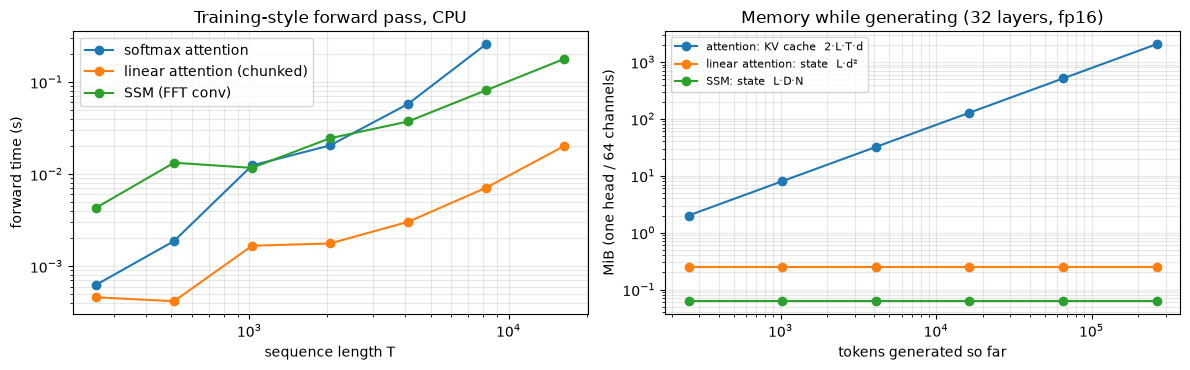

In [19]:
def softmax_attn(q, k, v):
    T, d = q.shape[1], q.shape[2]
    s = (q @ k.transpose(1, 2)) / math.sqrt(d)
    s = s.masked_fill(torch.triu(torch.ones(T, T, dtype=torch.bool), 1), float("-inf"))
    return s.softmax(-1) @ v

def bench(fn, *args, reps=5):
    fn(*args); best = math.inf
    for _ in range(reps):
        t0 = time.perf_counter(); fn(*args); best = min(best, time.perf_counter() - t0)
    return best

d, Nst = 64, 16
Ts = [256, 512, 1024, 2048, 4096, 8192, 16384]
res = {"softmax attention": [], "linear attention (chunked)": [], "SSM (FFT conv)": []}
a_b = torch.rand(d, Nst) * 0.1 + 0.9; b_b, c_b = torch.randn(d, Nst), torch.randn(d, Nst)
with torch.no_grad():
    for T in Ts:
        q, k, v = (torch.randn(1, T, d) for _ in range(3))
        res["softmax attention"].append(bench(softmax_attn, q, k, v) if T <= 8192 else np.nan)
        res["linear attention (chunked)"].append(bench(linattn_chunked, q, k, v))
        res["SSM (FFT conv)"].append(bench(lambda x: causal_conv_fft(x, ssm_kernel(a_b, b_b, c_b, x.shape[1])), v))
        print(f"T={T:6d}  " + "  ".join(f"{n}: {r[-1] * 1e3:7.1f} ms" for n, r in res.items()))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for n, r in res.items():
    ax[0].plot(Ts, r, marker="o", label=n)
ax[0].set(xscale="log", yscale="log", xlabel="sequence length T", ylabel="forward time (s)", title="Training-style forward pass, CPU")
ax[0].legend(); ax[0].grid(alpha=.3, which="both")
pos = np.array([256, 1024, 4096, 16384, 65536, 262144])
L = 32                                                         # layers, fp16 bytes
ax[1].plot(pos, 2 * L * pos * d * 2 / 2**20, marker="o", label="attention: KV cache  2·L·T·d")
ax[1].plot(pos, np.full(len(pos), L * d * d * 2 / 2**20), marker="o", label="linear attention: state  L·d²")
ax[1].plot(pos, np.full(len(pos), L * d * Nst * 2 / 2**20), marker="o", label="SSM: state  L·D·N")
ax[1].set(xscale="log", yscale="log", xlabel="tokens generated so far", ylabel="MiB (one head / 64 channels)", title="Memory while generating (32 layers, fp16)")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

Softmax attention's time grows at least 4× per doubling of $T$ at the top end (slope ≥ 2 on the log-log plot: $O(T^2)$, worse once the $T\times T$ matrix no longer fits in cache); chunked linear attention grows ≈2× per doubling ($O(T)$) and is more than 10× faster from $T=4096$ on. (Wall-clock timings on a laptop are noisy; read the slopes, not single points.) The FFT SSM ($O(T\log T)$, including building the kernel) is *slower* than softmax attention up to $T=2048$ and faster at $T=8192$, with the crossover in between: at short lengths one dense matrix multiply is hard to beat, which is why short-context models never needed these layers. During generation the gap is in memory: the KV cache grows linearly without bound, the linear-attention / SSM state is constant.
The price of the fixed state: it cannot store every past token, so exact recall (copying, needle-in-a-haystack) degrades. Production hybrids keep ~1 full-attention layer in 4–8.

✏️ In the selective SSM, what does the model do when it drives $a_t\to0$ at some step? And $a_t\to1$? Relate to the LSTM forget gate.

## 5. Gradients through time: how far back does the loss reach?

The recap says vanilla RNN gradients vanish because $\partial h_T/\partial h_t$ is a product of $T-t$ Jacobians. Let's measure it. Same input sequence ($T=100$), loss = a random linear readout of the **last** state only, and record $\lVert\partial L/\partial h_t\rVert$ for every step $t$ (`retain_grad` on each state). Untrained models, PyTorch default initialization:
- vanilla RNN, $H=64$;
- LSTM, $H=64$, and the same LSTM with the **forget-gate bias set to 1 or 3** (Gers et al. 2000; Jozefowicz et al. 2015 recommend 1), a one-line change;
- the diagonal SSM from section 4 ($16$ channels × $4$ states $= 64$ numbers), decays $a\in[0.90, 0.999]$.

For the LSTM we take the gradient w.r.t. the cell $c_t$ (the highway) and w.r.t. $h_t$.

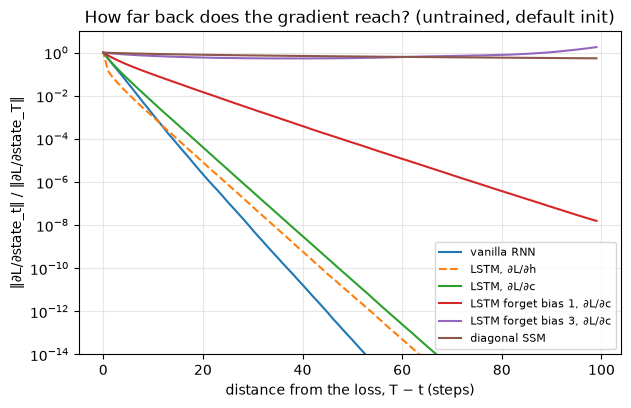

vanilla RNN                  relative gradient at distance 10: 1.3e-03   at 50: 4.7e-14   at 99: 0.0e+00
LSTM, ∂L/∂h                  relative gradient at distance 10: 1.0e-03   at 50: 5.5e-12   at 99: 8.2e-22
LSTM, ∂L/∂c                  relative gradient at distance 10: 4.9e-03   at 50: 2.8e-11   at 99: 3.4e-21
LSTM forget bias 1, ∂L/∂c    relative gradient at distance 10: 9.7e-02   at 50: 6.8e-05   at 99: 1.6e-08
LSTM forget bias 3, ∂L/∂c    relative gradient at distance 10: 7.0e-01   at 50: 5.6e-01   at 99: 1.8e+00
diagonal SSM                 relative gradient at distance 10: 8.7e-01   at 50: 6.7e-01   at 99: 5.5e-01


In [20]:
torch.manual_seed(0)
T, Din, H, Bsz = 100, 16, 64, 32
xs = torch.randn(Bsz, T, Din, requires_grad=True)   # so every state is part of the autograd graph

def grad_profile(step, state, pick):
    # unroll, keep every state, backprop a readout of the LAST state, return ||dL/dstate_t|| for t = 1..T
    kept = []
    for t in range(T):
        state = step(xs[:, t], state)
        s = pick(state); s.retain_grad(); kept.append(s)
    (kept[-1] * torch.randn_like(kept[-1])).sum().backward()
    g = torch.tensor([s.grad.norm().item() for s in kept])
    return (g / g[-1]).numpy()                 # relative to the gradient at the last step

rnn = nn.RNNCell(Din, H)
lstm = nn.LSTMCell(Din, H)
def with_forget_bias(cell, value):
    new = nn.LSTMCell(Din, H); new.load_state_dict(cell.state_dict())
    with torch.no_grad():
        new.bias_ih[H:2 * H] = value; new.bias_hh[H:2 * H] = 0.0
    return new
Nst = 4
a_s = torch.exp(-torch.exp(torch.empty(Din, Nst).uniform_(math.log(1e-3), math.log(1e-1))))
b_s = torch.randn(Din, Nst)

z = lambda: torch.zeros(Bsz, H)
lstm_step = lambda cell: (lambda x, s: lstm_cell(x, s, cell.weight_ih, cell.weight_hh, cell.bias_ih, cell.bias_hh))
profiles = {
    "vanilla RNN": grad_profile(lambda x, h: rnn_cell(x, h, rnn.weight_ih, rnn.weight_hh, rnn.bias_ih, rnn.bias_hh), z(), lambda s: s),
    "LSTM, ∂L/∂h": grad_profile(lstm_step(lstm), (z(), z()), lambda s: s[0]),
    "LSTM, ∂L/∂c": grad_profile(lstm_step(lstm), (z(), z()), lambda s: s[1]),
    "LSTM forget bias 1, ∂L/∂c": grad_profile(lstm_step(with_forget_bias(lstm, 1.0)), (z(), z()), lambda s: s[1]),
    "LSTM forget bias 3, ∂L/∂c": grad_profile(lstm_step(with_forget_bias(lstm, 3.0)), (z(), z()), lambda s: s[1]),
    "diagonal SSM": grad_profile(lambda x, h: a_s * h + b_s * x[..., None], torch.zeros(Bsz, Din, Nst), lambda s: s),
}
dist = np.arange(T)[::-1]                      # T − t: steps between the state and the loss
plt.figure(figsize=(7, 4.2))
for name, g in profiles.items():
    plt.plot(dist, g, label=name, ls="--" if "∂h" in name else "-")
plt.yscale("log"); plt.ylim(1e-14, 10)
plt.xlabel("distance from the loss, T − t (steps)"); plt.ylabel("‖∂L/∂state_t‖ / ‖∂L/∂state_T‖")
plt.title("How far back does the gradient reach? (untrained, default init)"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.show()
for name, g in profiles.items():
    print(f"{name:28s} relative gradient at distance 10: {g[-11]:.1e}   at 50: {g[-51]:.1e}   at 99: {g[0]:.1e}")

- **Vanilla RNN**: the gradient shrinks by a factor ≈0.5 per step: $10^{-3}$ at 10 steps back, $5\cdot10^{-14}$ at 50, and it underflows to exactly 0 in float32 by 99. Whatever happened 20 steps ago cannot affect learning.
- **LSTM at default init is not much better** ($5\cdot10^{-3}$ at 10 steps, $10^{-11}$ at 50). The cell path is free of $W$, but it is still multiplied by $f_t$ at every step, and with biases near 0 the forget gate sits at $\sigma(0)\approx0.5$. The "uninterrupted gradient flow" of the lecture holds only when $f\approx1$.
- **Forget bias 1** ($\sigma(1)=0.73$): $10^{-1}$ at 10 steps, $10^{-8}$ at 99. **Forget bias 3** ($\sigma(3)=0.95$): the gradient stays within a factor of 2 of its value at the loss over all 100 steps. One bias value changes the reach by 20 orders of magnitude.
- **Diagonal SSM**: no nonlinearity and decays $a\in[0.90,0.999]$, so the gradient through channel $n$ is exactly $a_n^{T-t}$; the slow channels dominate and the total is still 0.55 at 99 steps. This is the reason S4/Mamba parametrize $a$ with timescales spread over orders of magnitude.

These are untrained profiles; training moves the gates. They still decide whether the first gradient steps can see long-range structure at all.
The practical rules that follow: initialize the LSTM forget bias to 1 (some libraries do it for you; PyTorch does not); clip gradients for the exploding case; and if a task needs dependencies hundreds of steps long, use a gated or state-space recurrence (or attention), not a vanilla RNN.

✏️ Scale the vanilla RNN's `weight_hh` by 3 (`rnn.weight_hh.data *= 3`) and re-run. Does the gradient still vanish? What does `tanh` saturation do to the Jacobian $\mathrm{diag}(1-h^2)W_{hh}$?

**Past exam question (Moed C, 2026), backpropagation through time**

A vanilla RNN with a scalar hidden state runs on an input sequence of length 3. Figure, in words: a chain $h_0=0 \to h_1 \to h_2 \to h_3$ with weight $w_h$ on every recurrent edge; input $x_t$ enters $h_t$ with weight $w_x$; the output $\hat y$ is computed from $h_3$ with weight $v$. For $t\in\{1,2,3\}$:
$$z_t = w_xx_t + w_hh_{t-1},\qquad h_t=\tanh(z_t),\qquad h_0=0,\qquad \hat y = v\,h_3,\qquad \tanh'(z) = 1-\tanh^2(z),$$
$$L = \tfrac12(y-\hat y)^2 + \tfrac{\lambda}{2}\big(w_x^2+w_h^2+v^2\big),\qquad \lambda>0.$$
The weights $w_x, w_h, v$ are shared across time steps.

**(a)** Give algebraic expressions for $\frac{\partial L}{\partial \hat y}$, $\frac{\partial L}{\partial v}$, $\frac{\partial L}{\partial h_3}$, $\frac{\partial L}{\partial h_2}$, and $\frac{\partial L}{\partial w_h}$ (sum the contributions of every step in which $w_h$ appears).

**(b)** The same architecture is extended to a long sequence of $T\gg3$ steps, $\hat y = v\,h_T$. In BPTT, $\partial L/\partial w_h$ contains the product $\prod_{t=k+1}^{T}(1-h_t^2)\,w_h$ on the way from $h_T$ back to $h_k$ ($k\ll T$). Under which conditions on $w_h$ and on the hidden states $\{h_t\}$ does this product decay exponentially with the sequence length (vanishing gradient)? What does this mean in practice for training the RNN on long sequences? Propose **one architectural change** that reduces the problem and explain briefly how it works.

**(a)** $\frac{\partial L}{\partial\hat y} = \hat y - y$, $\;\frac{\partial L}{\partial v} = (\hat y-y)h_3 + \lambda v$, $\;\frac{\partial L}{\partial h_3} = (\hat y-y)v$, $\;\frac{\partial L}{\partial h_2} = (\hat y-y)\,v\,(1-h_3^2)\,w_h$.
With $\delta_t = \partial L/\partial z_t$: $\delta_3 = (\hat y-y)v(1-h_3^2)$, $\delta_2 = \delta_3 w_h(1-h_2^2)$, $\delta_1 = \delta_2 w_h (1-h_1^2)$, and since $\partial z_t/\partial w_h = h_{t-1}$,
$$\frac{\partial L}{\partial w_h} = \delta_3h_2 + \delta_2h_1 + \delta_1h_0 + \lambda w_h = \delta_3h_2+\delta_2h_1+\lambda w_h\quad(h_0=0).$$
**(b)** $0 < 1-h_t^2\le1$, so the product decays exponentially when $|w_h|(1-h_t^2) < 1$ for most steps: always if $|w_h|<1$, and also for larger $|w_h|$ when the states saturate ($|h_t|\to1$, so $1-h_t^2\to0$). In practice the gradient from the loss at step $T$ does not reach early steps, so the RNN cannot learn long-range dependencies (section 5 measured ~$10^{-3}$ after 10 steps for a vanilla RNN). Fix: an **LSTM/GRU**. The cell state is updated additively, $c_t = f_t\odot c_{t-1} + i_t\odot g_t$, so $\partial c_t/\partial c_{t-1} = f_t$, with no $w_h$ and no $\tanh'$; with the forget gate near 1 the gradient survives hundreds of steps (forget-bias curves above).

In [21]:
torch.manual_seed(1)
xs_q = torch.randn(3, dtype=torch.float64)
w_x, w_h, v_q = (torch.randn((), dtype=torch.float64, requires_grad=True) for _ in range(3))
y_q, lam = 0.7, 0.1
hs = [torch.zeros((), dtype=torch.float64)]
for t in range(3):
    hs.append(torch.tanh(w_x * xs_q[t] + w_h * hs[-1]))
y_hat = v_q * hs[3]
L = 0.5 * (y_q - y_hat) ** 2 + lam / 2 * (w_x ** 2 + w_h ** 2 + v_q ** 2)
L.backward()
h0, h1, h2, h3 = (h.item() for h in hs); wh, v_ = w_h.item(), v_q.item(); r = y_hat.item() - y_q
dv = r * h3 + lam * v_
d3 = r * v_ * (1 - h3 ** 2)
d2 = d3 * wh * (1 - h2 ** 2)
d1 = d2 * wh * (1 - h1 ** 2)
dwh = d3 * h2 + d2 * h1 + d1 * h0 + lam * wh
print(f"dL/dv  : formula {dv:.10f}   autograd {v_q.grad.item():.10f}")
print(f"dL/dw_h: formula {dwh:.10f}   autograd {w_h.grad.item():.10f}")

dL/dv  : formula -0.0469057567   autograd -0.0469057567
dL/dw_h: formula -0.0669936875   autograd -0.0669936875


## 6. If time: a GRU cell by hand

PyTorch's GRU (gate order **r, z, n** in `weight_ih` / `weight_hh`):
$$r=\sigma(W_{ir}x+b_{ir}+W_{hr}h+b_{hr}),\quad z=\sigma(W_{iz}x+b_{iz}+W_{hz}h+b_{hz}),$$
$$n=\tanh\big(W_{in}x+b_{in}+r\odot(W_{hn}h+b_{hn})\big),\qquad h'=(1-z)\odot n+z\odot h.$$
One state, two gates; $z$ plays the forget gate and $1-z$ the input gate, tied.

In [22]:
def gru_cell(x, h, W_ih, W_hh, b_ih, b_hh):
    gi, gh = x @ W_ih.T + b_ih, h @ W_hh.T + b_hh
    i_r, i_z, i_n = gi.chunk(3, -1); h_r, h_z, h_n = gh.chunk(3, -1)
    r, z = torch.sigmoid(i_r + h_r), torch.sigmoid(i_z + h_z)
    n = torch.tanh(i_n + r * h_n)
    return (1 - z) * n + z * h

torch.manual_seed(0)
ref = nn.GRUCell(10, 20); x, h = torch.randn(4, 10), torch.randn(4, 20)
print("GRU cell max |mine − torch| =", (gru_cell(x, h, ref.weight_ih, ref.weight_hh, ref.bias_ih, ref.bias_hh) - ref(x, h)).abs().max().item())

GRU cell max |mine − torch| = 1.1920928955078125e-07


## Summary
- **BPE** learns an ordered list of merges from frequent byte pairs; encoding replays them by rank. The round trip is lossless for any string; on held-out Shakespeare 756 tokens give 2.1 characters per token, GPT-2's 50k give 3.1.
- An **LSTM layer** is a loop over a cell with four gates from one matrix multiply; ours matches `nn.LSTM` to float precision once the weights are copied.
- An **autoregressive LM** is trained with teacher forcing (targets = inputs shifted by one) and sampled one token at a time; temperature trades diversity for coherence.
- A **linear recurrence** (diagonal SSM, linear attention) has three equivalent forms: recurrent (constant memory per token), convolution (time-invariant only, FFT), and parallel scan (also for input-dependent, *selective* decay). Linear in $T$, but a fixed state cannot remember everything, hence attention + SSM **hybrids**.
- **Gradients through time** shrink geometrically in a vanilla RNN; the LSTM cell path and slowly decaying SSM states carry them much further, and the forget-gate bias controls how far.

**Further watching:**
- Stanford CS231n (2017), Lecture 10: Recurrent Neural Networks: https://www.youtube.com/watch?v=6niqTuYFZLQ
- Karpathy, *makemore part 1* (bigram character LM): https://www.youtube.com/watch?v=PaCmpygFfXo
- Karpathy, *makemore part 2* (MLP character LM): https://www.youtube.com/watch?v=TCH_1BHY58I
- Karpathy, *Let's build the GPT Tokenizer* (section 2 follows it): https://www.youtube.com/watch?v=zduSFxRajkE